<a href="https://colab.research.google.com/github/ftzanha00-max/STUDENT-PERFORMANCE-ANALYSIS-/blob/main/Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student_academic_performance.csv to student_academic_performance.csv


In [ ]:
import pandas as pd

df = pd.read_csv("student_academic_performance.csv")

print(df.head())

   Student ID  Gender Race/Ethnicity Parental Education    Lunch Type  \
0           1  female        group B       some college      standard   
1           2    male        group D        high school      standard   
2           3    male        group B    bachelor degree  free/reduced   
3           4    male        group E        high school      standard   
4           5  female        group C    bachelor degree      standard   

   Test Preparation  Study Time per Week  Daily Sleep Duration  Math Score  \
0             False                 12.4                   5.4        62.0   
1             False                 18.3                   5.1        74.0   
2              True                 11.8                   7.8        71.0   
3             False                  NaN                   7.3        83.0   
4              True                 12.9                   6.3        41.0   

   Reading Score  Writing Score School Type Internet Access  
0           76.0           65.

In [ ]:
print(df.columns)

Index(['Student ID', 'Gender', 'Race/Ethnicity', 'Parental Education',
       'Lunch Type', 'Test Preparation', 'Study Time per Week',
       'Daily Sleep Duration', 'Math Score', 'Reading Score', 'Writing Score',
       'School Type', 'Internet Access'],
      dtype='object')


In [ ]:
print(df.shape)

(7000, 13)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("student_academic_performance.csv")

# Display first rows
print(df.head())

# Select numerical columns only
numeric_df = df.select_dtypes(include=np.number)

# Display numerical columns
print("\nNumerical Columns:")
print(numeric_df.columns)

# Choose target column
# Replace the target column if needed
target_column = numeric_df.columns[-1]

X = numeric_df.drop(columns=[target_column])
y = numeric_df[target_column]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print metrics
print("\nModel Evaluation")
print("R2 Score :", r2)
print("MAE       :", mae)
print("RMSE      :", rmse)

# Graph 1: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# Graph 2: Residual Errors
errors = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, errors)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")
plt.show()

   Student ID  Gender Race/Ethnicity Parental Education    Lunch Type  \
0           1  female        group B       some college      standard   
1           2    male        group D        high school      standard   
2           3    male        group B    bachelor degree  free/reduced   
3           4    male        group E        high school      standard   
4           5  female        group C    bachelor degree      standard   

   Test Preparation  Study Time per Week  Daily Sleep Duration  Math Score  \
0             False                 12.4                   5.4        62.0   
1             False                 18.3                   5.1        74.0   
2              True                 11.8                   7.8        71.0   
3             False                  NaN                   7.3        83.0   
4              True                 12.9                   6.3        41.0   

   Reading Score  Writing Score School Type Internet Access  
0           76.0           65.

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Numerical Columns:
Index(['Student ID', 'Study Time per Week', 'Daily Sleep Duration',
       'Math Score', 'Reading Score', 'Writing Score'],
      dtype='object')

Model Evaluation
R2 Score : -0.0007110199407898143
MAE       : 10.118009678641528
RMSE      : 12.882259278999078


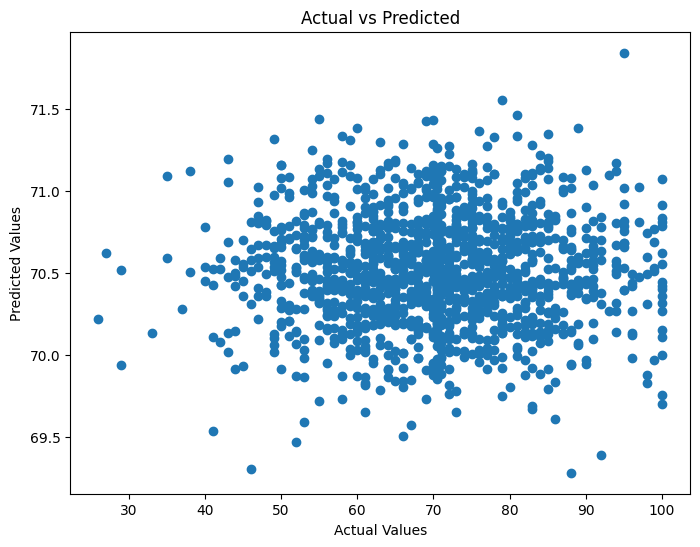

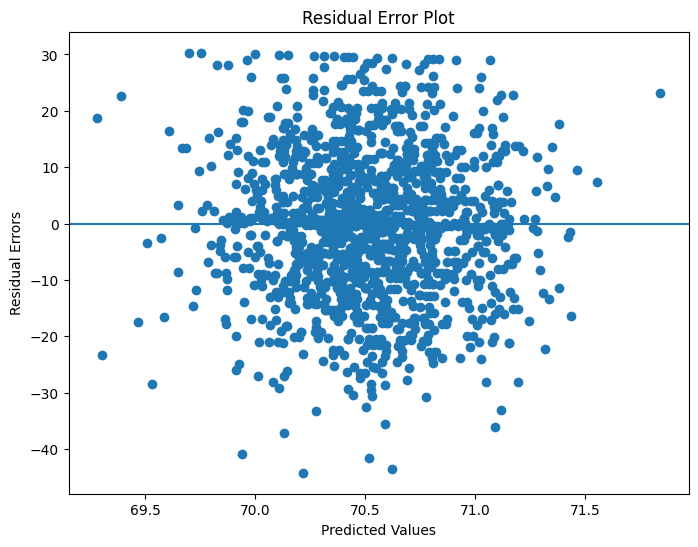

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv("student_academic_performance.csv")

# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

print("Numerical Columns:")
print(numeric_df.columns)

# Target column
target_column = "Writing Score"

# Features and target
X = numeric_df.drop(columns=[target_column])
y = numeric_df[target_column]

# Handle missing values using mean
imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(X)

# Handle missing values in target
y = y.fillna(y.mean())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation")
print("R2 Score :", r2)
print("MAE       :", mae)
print("RMSE      :", rmse)

# ---------------- GRAPH 1 ----------------
# Actual vs Predicted

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

# ---------------- GRAPH 2 ----------------
# Residual Error Plot

errors = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, errors)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")

plt.show()